In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load the hierarchical results from the file
file_path = "newThesis/heirarical_result1.txt"  # Adjust path to match your directory structure
with open(file_path, 'r') as file:
    data = file.read()

# Extract information using regular expressions
epochs = re.findall(r"Epoch (\d+)/\d+", data)
train_losses = re.findall(r"Train Loss: ([\d.]+)", data)
val_losses = re.findall(r"Val Loss:\s+([\d.]+)", data)

metrics = ['phylum', 'class', 'order', 'family', 'genus', 'species']
train_accuracies = {metric: re.findall(fr"Train Acc {metric}: ([\d.]+)%", data) for metric in metrics}
val_accuracies = {metric: re.findall(fr"Val Acc {metric}: ([\d.]+)%", data) for metric in metrics}

# Convert to DataFrame for easier manipulation
df = pd.DataFrame({
    "Epoch": list(map(int, epochs)),
    "Train Loss": list(map(float, train_losses)),
    "Val Loss": list(map(float, val_losses))
})
for metric in metrics:
    df[f"Train Acc {metric}"] = list(map(float, train_accuracies[metric]))
    df[f"Val Acc {metric}"] = list(map(float, val_accuracies[metric]))

# Plot losses separately
plt.figure(figsize=(12, 6))
plt.plot(df['Epoch'], df['Train Loss'], label="Train Loss", linestyle='--', marker='o')
plt.plot(df['Epoch'], df['Val Loss'], label="Validation Loss", linestyle='-', marker='x')
plt.title("Loss Progression (No mlm training)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Define a consistent color palette for each taxonomic level
colors = {
    "phylum": "blue",
    "class": "orange",
    "order": "green",
    "family": "red",
    "genus": "purple",
    "species": "brown"
}

# Plot all accuracies in a single plot with consistent colors
plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(
        df['Epoch'],
        df[f'Train Acc {metric}'],
        label=f"Train Acc {metric}",
        linestyle='--',
        marker='',
        color=colors[metric]
    )
    plt.plot(
        df['Epoch'],
        df[f'Val Acc {metric}'],
        label=f"Validation Acc {metric}",
        linestyle='-',
        marker='',
        color=colors[metric]
    )

plt.title("Accuracy Progression Across Taxonomic Levels (No mlm training)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Place legend outside the plot
plt.grid()
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'newThesis/heirarical_result1.txt'

# Now with pretraining

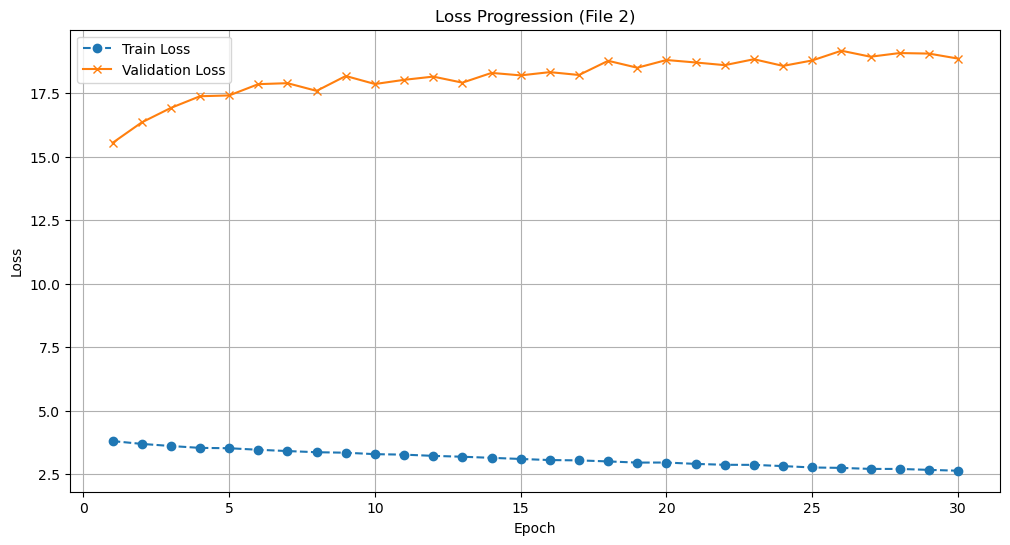

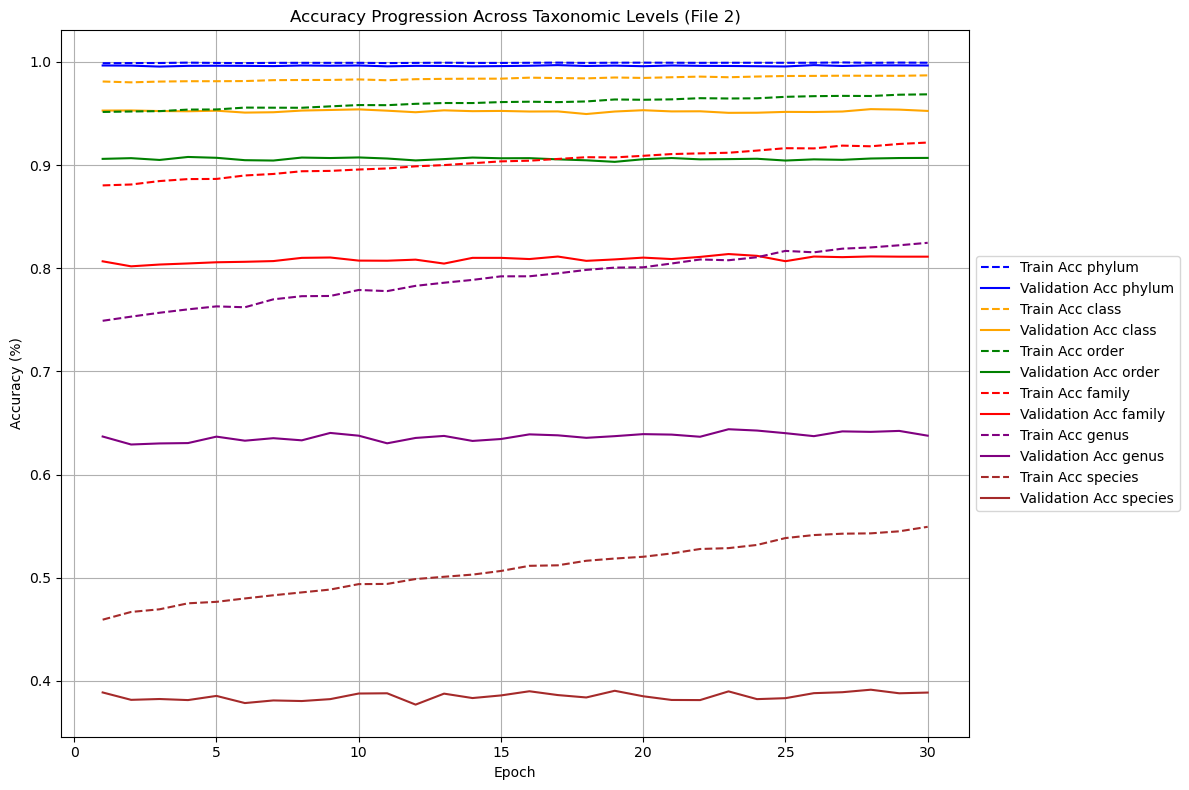

In [2]:
import ast
import pandas as pd
import matplotlib.pyplot as plt

# Load the hierarchical results from the file
file_path = "newThesis/results2.txt"
with open(file_path, 'r') as file:
    data = ast.literal_eval(file.read())  # Safely evaluate the string as a Python dictionary

# Extract the data from the structure
epochs = list(range(1, len(data['train_losses']) + 1))
train_losses = data['train_losses']
val_losses = data['val_losses']
train_accuracies = data['train_accuracies']
val_accuracies = data['val_accuracies']
metrics = list(train_accuracies.keys())

# Convert to a DataFrame for easier plotting
df = pd.DataFrame({
    "Epoch": epochs,
    "Train Loss": train_losses,
    "Val Loss": val_losses
})
for metric in metrics:
    df[f"Train Acc {metric}"] = train_accuracies[metric]
    df[f"Val Acc {metric}"] = val_accuracies[metric]

# Plot losses separately
plt.figure(figsize=(12, 6))
plt.plot(df['Epoch'], df['Train Loss'], label="Train Loss", linestyle='--', marker='o')
plt.plot(df['Epoch'], df['Val Loss'], label="Validation Loss", linestyle='-', marker='x')
plt.title("Loss Progression (File 2)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

# Define a consistent color palette for each taxonomic level
colors = {
    "phylum": "blue",
    "class": "orange",
    "order": "green",
    "family": "red",
    "genus": "purple",
    "species": "brown"
}

# Plot all accuracies in a single plot with consistent colors
plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(
        df['Epoch'],
        df[f'Train Acc {metric}'],
        label=f"Train Acc {metric}",
        linestyle='--',
        marker='',
        color=colors[metric]
    )
    plt.plot(
        df['Epoch'],
        df[f'Val Acc {metric}'],
        label=f"Validation Acc {metric}",
        linestyle='-',
        marker='',
        color=colors[metric]
    )

plt.title("Accuracy Progression Across Taxonomic Levels (File 2)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Place legend outside the plot
plt.grid()
plt.tight_layout()
plt.show()


# Investigate the uncertainty in the dataset

In [6]:
from src.data.data_tools import filter_taxonomy, fasta2pandas
all_data = fasta2pandas("src/data/raw.fasta")
all_data.head()

,kingdom,phylum,class,order,family,genus,species,sequence
0,Fungi,Ascomycota,Eurotiomycetes,Verrucariales,Verrucariaceae,Endocarpon,Endocarpon_psorodeum,AAGGATCATTATCGAGTGGGGGTCCTCTGGGCCCCGTCTCCAACCC...
1,Fungi,Ascomycota,Dothideomycetes,Stigmatodiscales,Stigmatodiscaceae,Stigmatodiscus,Stigmatodiscus_enigmaticus,CCGAGCGCGCAGCCCCTTAGGGGGTTGTCCTCACATCCGCTGTGTA...
2,Fungi,Rozellomycota,Rozellomycota_cls_Incertae_sedis,Rozellomycota_ord_Incertae_sedis,Rozellomycota_fam_Incertae_sedis,Rozellomycota_gen_Incertae_sedis,Rozellomycota_sp,ACAAATTCAACCAACCACACAACACACCTGTGAACCGGTCGGTGCA...
3,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Hygrophoraceae,Hygrophoraceae_gen_Incertae_sedis,Hygrophoraceae_sp,ACGAATAAATTTTTGAGGATGTTGCTGGTCTTGTCTTTCGGGATGG...
4,Fungi,Basidiomycota,Agaricomycetes,Sebacinales,Serendipitaceae,Serendipita,Serendipita_sp,GTGAAACTTCAAAGTCGGCTCGTCACACTGTGCTGGTGGAGACACA...


In [12]:
import pandas as pd
import json

# Define a function to check for uncertainty notations in a string
def extract_uncertainties(value):
    if pd.isna(value):  # Handle NaN values gracefully
        return None
    # Updated regex patterns to match underscore-separated notations
    uncertainty_patterns = [
        r'_cf\.',                # "_cf." (compare with)
        r'_aff\.',               # "_aff." (affinity to)
        #r'_sp$',                 # "_sp" (species)
        #r'_sp\.',                # "_sp." (species abbreviation)
        #r'_incertae_sedis$',     # "_incertae_sedis" (uncertain placement)
        r'_nom\.dub\.',          # "_nom.dub." (doubtful name)
        r'_nom\.nud\.',          # "_nom.nud." (naked name)
        r'_group$',              # "_group" (informal grouping)
        r'_complex$',            # "_complex" (cryptic species complex)
        r'_aggregate$',          # "_aggregate" (species aggregate)
        r'\?',                   # "?" (uncertainty marker)
        r'_sensu_lato$',         # "_sensu_lato" (in the broad sense)
        r'_sensu_stricto$',      # "_sensu_stricto" (in the strict sense)
    ]
    # Check each pattern and return the value if any match
    for pattern in uncertainty_patterns:
        if pd.Series(value).str.contains(pattern, case=False, regex=True).any():
            return value
    return None

# List of taxonomic columns
taxonomic_columns = ['kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']

# Create a dictionary to store uncertainties by taxonomic level
uncertainty_dict = {level: [] for level in taxonomic_columns}

# Process each column
for column in taxonomic_columns:
    print(f"Processing column: {column}")  # Print the column being processed
    # Extract unique values from the column
    unique_values = set(all_data[column].dropna())  # Convert to a set for uniqueness and speed
    print(f"  Found {len(unique_values)} unique values in column '{column}'")

    # Check each unique value for uncertainties
    uncertainties = [value for value in unique_values if extract_uncertainties(value)]
    uncertainty_dict[column] = uncertainties  # Store the uncertainties
    print(f"  Found {len(uncertainties)} uncertainties in column '{column}'")

# Save or display the results
for level, values in uncertainty_dict.items():
    print(f"{level}_uncertainties: {values}")

# Optionally save the dictionary as a JSON file
# with open('taxonomic_uncertainties.json', 'w') as json_file:
#     json.dump(uncertainty_dict, json_file, indent=4)


Processing column: kingdom
  Found 1 unique values in column 'kingdom'
  Found 0 uncertainties in column 'kingdom'
Processing column: phylum
  Found 21 unique values in column 'phylum'
  Found 0 uncertainties in column 'phylum'
Processing column: class
  Found 109 unique values in column 'class'
  Found 0 uncertainties in column 'class'
Processing column: order
  Found 372 unique values in column 'order'
  Found 0 uncertainties in column 'order'
Processing column: family
  Found 1177 unique values in column 'family'
  Found 0 uncertainties in column 'family'
Processing column: genus
  Found 5971 unique values in column 'genus'
  Found 0 uncertainties in column 'genus'
Processing column: species
  Found 31684 unique values in column 'species'
  Found 0 uncertainties in column 'species'
kingdom_uncertainties: []
phylum_uncertainties: []
class_uncertainties: []
order_uncertainties: []
family_uncertainties: []
genus_uncertainties: []
species_uncertainties: []
